In [1]:
!pip install networkx python-louvain

 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 4.5 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9460 sha256=82b86934f7e128ec7e639e156975a1e660fb055dad978f4b369fe6f1324b2ca9
  Stored in directory: /home/marcelly/.cache/pip/wheels/40/f1/e3/485b698c520fa0baee1d07897abc7b8d6479b7d199ce96f4af
Successfully built python-louvain


In [ ]:
#--BUILD k-NN GRAPH WITH SelectedClean_nhis2023.csv--#

In [1]:
#Normalize AGEP_A between [0-1]
import pandas as pd
import numpy as np

df = pd.read_csv("SelectedClean_nhis2023.csv")

AGE_COL = "AGEP_A"
#compute min/max 
age_min = float(df[AGE_COL].min())
age_max = float(df[AGE_COL].max())

def add_scaled_age(df_in, age_col=AGE_COL, age_min=age_min, age_max=age_max, out_col=None):
    if out_col is None:
        out_col = f"{age_col}_scaled"
    if pd.isna(age_min) or pd.isna(age_max) or age_max <= age_min:
        df_in[out_col] = 0.0  # degenerate case: avoid divide-by-zero
    else:
        df_in[out_col] = (df_in[age_col] - age_min) / (age_max - age_min)
    return df_in

#create a working copy 
df_scaled_age = add_scaled_age(df.copy(), age_col=AGE_COL, age_min=age_min, age_max=age_max)

print(df_scaled_age.columns.tolist())             
print(df_scaled_age[['AGEP_A','AGEP_A_scaled']].head())




['HISPALLP_A', 'SEX_A', 'AGEP_A', 'ANXEV_A', 'AGEP_A_scaled']
   AGEP_A  AGEP_A_scaled
0      67       0.604938
1      73       0.679012
2      48       0.370370
3      42       0.296296
4      50       0.395062


In [2]:
##Checking for best k 
import numpy as np
import pandas as pd
from sklearn.neighbors import kneighbors_graph
from scipy.sparse import csr_matrix, csgraph

def sweep_k_for_knn_age(
    df_scaled: pd.DataFrame,
    scaled_col: str = "AGEP_A_scaled",
    ks = tuple(range(3, 31)),     # k values to try
    target_gcc: float = 0.98,     # target giant component coverage
    dtype=np.float32,
    compute_weights: bool = True,  # Cmpute RBF sigma & mean similarity
    age_col: str | None = "AGEP_A",
    age_min: float | None = None,
    age_max: float | None = None,
    verbose: bool = True,
):

    X = df_scaled[[scaled_col]].to_numpy(dtype=dtype, copy=False)
    n = X.shape[0]
    results = []

    for k in ks:
        k_eff = min(max(1, k), max(1, n-1))  # guard

        # kNN distances (Euclidean in 1D), directed 
        A_dist = kneighbors_graph(
            X, n_neighbors=k_eff, mode="distance",
            metric="euclidean", include_self=False, n_jobs=-1
        ).tocsr().astype(dtype)

        # unweighted, undirected union graph for connectivity stats 
        U = (A_dist + A_dist.T)            # union
        U.data[:] = 1.0                    # binarize
        U = U.tocsr()                      # ensure CSR

        # connected components
        n_comp, labels = csgraph.connected_components(U, directed=False)
        # giant component fraction
        if n_comp > 0:
            _, counts = np.unique(labels, return_counts=True)
            gcc_frac = counts.max() / n
        else:
            gcc_frac = 0.0

        # edges & degree
        undirected_edges = U.nnz // 2
        mean_degree = float(U.sum(axis=1).mean())

        row = {
            "k": k_eff,
            "n_components": n_comp,
            "giant_component_frac": gcc_frac,
            "edges_undirected": undirected_edges,
            "mean_degree": mean_degree,
        }

        # convert distances into RBF weights and summarize
        if compute_weights:
            nz = A_dist.data
            sigma = float(np.median(nz)) if nz.size else 1.0
            W = A_dist.tocsr(copy=True)
            W.data = np.exp(-(W.data**2) / (2.0 * sigma**2 + 1e-12)).astype(dtype)
            W = ((W + W.T) * 0.5).tocsr()  # symmetric
            row.update({
                "sigma_median": sigma,
                "mean_similarity": float(W.data.mean()) if W.nnz else 0.0
            })

        results.append(row)

    df_res = pd.DataFrame(results).sort_values("k").reset_index(drop=True)

    
    # pick the smallest k 
    candidates = df_res[df_res["giant_component_frac"] >= target_gcc]
    if not candidates.empty:
        # keep mean_degree below a soft upper bound (e.g., <= 25)
        soft_cap = candidates[candidates["mean_degree"] <= 25]
        if not soft_cap.empty:
            recommended_k = int(soft_cap.iloc[0]["k"])
        else:
            recommended_k = int(candidates.iloc[0]["k"])
    else:
        # the k with the max giant component fraction; break ties by smaller k
        best_row = df_res.sort_values(
            ["giant_component_frac", "k"], ascending=[False, True]
        ).iloc[0]
        recommended_k = int(best_row["k"])

    sigma_star = None
    if compute_weights and "sigma_median" in df_res.columns:
        sigma_star = float(df_res.loc[df_res["k"] == recommended_k, "sigma_median"].iloc[0])

    # figure out the age bounds for the printout
    used_age_min = age_min
    used_age_max = age_max
    if (used_age_min is None or used_age_max is None) and age_col and (age_col in df_scaled.columns):
        used_age_min = float(df_scaled[age_col].min())
        used_age_max = float(df_scaled[age_col].max())


    if verbose:
        print(f"Recommended k: {recommended_k}")
        if sigma_star is not None:
            print(f"Sigma* (median kNN distance at k={recommended_k}): {sigma_star:.6f}")
        if used_age_min is not None and used_age_max is not None:
            print(f"Age scaling used: min={used_age_min:.3f}, max={used_age_max:.3f}")
        else:
            # fall back to scaled column range (if original min/max not provided)
            smin = float(df_scaled[scaled_col].min())
            smax = float(df_scaled[scaled_col].max())
            print(f"Scaled range for '{scaled_col}': [{smin:.6f}, {smax:.6f}]")

    return df_res, recommended_k


# Ensure df_scaled_age already has AGEP_A_scaled [0,1]
df_metrics, k_star = sweep_k_for_knn_age(
    df_scaled_age,
    scaled_col="AGEP_A_scaled",
    ks=range(5, 31),
    target_gcc=0.98,
    compute_weights=True,
    age_col="AGEP_A",          # so it can print original age bounds
    age_min=float(df_scaled_age["AGEP_A"].min()),  # optional but precise
    age_max=float(df_scaled_age["AGEP_A"].max()),
    verbose=True
)

print(df_metrics.head())
print("Recommended k:", k_star)

Recommended k: 30
Sigma* (median kNN distance at k=30): 0.000000
Age scaling used: min=18.000, max=99.000
   k  n_components  giant_component_frac  edges_undirected  mean_degree  \
0  5         29460              0.000034                 0     0.000000   
1  6         29454              0.000238                 6     0.000407   
2  7         29453              0.000272                12     0.000815   
3  8         29452              0.000305                18     0.001222   
4  9         29451              0.000339                24     0.001629   

   sigma_median  mean_similarity  
0           0.0         0.503590  
1           0.0         0.504176  
2           0.0         0.504766  
3           0.0         0.505359  
4           0.0         0.505954  
Recommended k: 30


In [3]:
#Building k-NN graph based on AGE only

# k-NN graph from AGE only (no protected attrs), RBF similarity on age
import json
import numpy as np
from sklearn.neighbors import kneighbors_graph #memory-efficient k-NN graph builder
from scipy import sparse

def build_knn_from_pre_scaled(
    df_scaled, scaled_col="AGEP_A_scaled",
    k=30, #number of nearest neighbors per node ( Recommended k)
    sigma=None, #width of the RBF/Gaussian kernel estimated from data
    mutual=False, #keep neighbors based on union (average the two directions).
    save_prefix="A_graph_age_rbf",  # name of output graph
    dtype=np.float32,# saving memory
    sigma_floor=1e-4  # small lower bound in scaled-age units
):
    X = df_scaled[[scaled_col]].to_numpy(dtype=dtype, copy=False) # array containing only pre-scaled age without unnecessary copies
    n = X.shape[0] # number of nodes
    if k >= n:
        k = max(1, n-1)

    # kNN distances in 1D (Euclidean)
    A_dist = kneighbors_graph(
        X, n_neighbors=k, mode="distance", # edge values are distances
        metric="euclidean", 
        include_self=False, n_jobs=-1 # avoids self-loops and sppedup with all CPU cores
    ).tocsr().astype(dtype) 

    # choose sigma based on estimate of the median of the non-zero neighbor distances
    if sigma is None:
        nz = A_dist.data
        pos = nz[nz > 0]  # ignore same-age zeros
        if pos.size:
            sigma = float(np.median(pos))
        else:
            # all neighbors at zero distance → pick a small but usable sigma
            sigma = 0.01
    sigma = max(float(sigma), sigma_floor)

    # distance -> RBF similarity, then symmetrize
    A_sim = A_dist.tocsr(copy=True)
    A_sim.data = np.exp(-(A_sim.data**2) / (2.0 * sigma**2 + 1e-12)).astype(dtype) # prevents division by zero if sigma is tiny
    A_sim = ((A_sim + A_sim.T) * 0.5).tocsr() #include edges appearing in either direction and average of the two weights

    # save outputs + minimal params (no age min/max needed because you pre-scaled)
    sparse.save_npz(f"{save_prefix}.npz", A_sim)
    params = {
        "scaled_col": scaled_col,
        "k": int(k),
        "sigma": float(sigma),
        "dtype": "float32",
        "mutual": bool(mutual),
        "similarity": "rbf_on_euclidean_age (pre-scaled)"
    }
    with open(f"{save_prefix}_params.json", "w") as f:
        json.dump(params, f, indent=2)

    print(f"Saved graph: {save_prefix}.npz  (nodes={n}, edges={A_sim.nnz//2} undirected approx.)")
    print(f"Saved params: {save_prefix}_params.json  (k={k}, sigma={sigma:.6f})")
    return A_sim, params
 
A_sim, params = build_knn_from_pre_scaled(
    df_scaled_age,
    scaled_col="AGEP_A_scaled",
    k=30,            
    sigma=None,      
    mutual=False,
    save_prefix="A_graph_age_rbf"
)


Saved graph: A_graph_age_rbf.npz  (nodes=29460, edges=851700 undirected approx.)
Saved params: A_graph_age_rbf_params.json  (k=30, sigma=0.024691)


In [4]:
print("Final sigma used:", params["sigma"])
print("Mean edge similarity:", float(A_sim.data.mean()) if A_sim.nnz else 0.0)

Final sigma used: 0.024691343307495117
Mean edge similarity: 0.5188099145889282


In [7]:
# Community detection with Leiden + summary table

import numpy as np
import pandas as pd
from scipy import sparse
import igraph as ig
import leidenalg as la

# Load graph + node table
A = sparse.load_npz("A_graph_age_rbf.npz").tocsr()

df_nodes = df_scaled_age.reset_index(drop=True).copy()


assert A.shape[0] == len(df_nodes), "Row count mismatch between A and df_nodes."

# Apply binarization mappings (adds new columns)
map_anx  = {'Yes': 1, 'No': 0}
map_sex  = {'Male': 0, 'Female': 1}
map_hisp = {
    'Non-Hispanic White only': 1,
    'Hispanic': 0,
    'Non-Hispanic Black/African American only': 0,
    'Non-Hispanic Asian only': 0,
    'Non-Hispanic AIAN only': 0,
    'Non-Hispanic AIAN and any other group': 0,
    'Multiple races': 0
}

df_nodes["ANXEV_A_bin"]  = df_nodes["ANXEV_A"].map(map_anx).astype(int)       # 1=Yes, 0=No
df_nodes["SEX_A_bin"]    = df_nodes["SEX_A"].map(map_sex).astype(int)         # 1=Female, 0=Male
df_nodes["HISPALLP_BIN"] = df_nodes["HISPALLP_A"].map(map_hisp).astype(int)   # 1=Non-Hisp White only, 0=Hisp+others

# Leiden community detection (RBConfiguration/CPM) 
def csr_to_igraph(A_csr):
    coo = A_csr.tocoo()
    g = ig.Graph(
        n=A_csr.shape[0],
        edges=list(zip(coo.row.tolist(), coo.col.tolist())),
        directed=False
    )
    g.es["weight"] = coo.data.tolist()
    return g

gamma = 1.0  # resolution; increase -> more/smaller communities, decrease -> fewer/larger
g = csr_to_igraph(A)
part = la.find_partition(
    g, la.RBConfigurationVertexPartition,
    weights="weight",
    resolution_parameter=gamma,
    seed=42
)
membership = np.array(part.membership, dtype=int)
quality = float(part.quality())
print(f"Leiden: detected {membership.max()+1} communities (gamma={gamma}), quality={quality:.4f}")

df_nodes["community"] = membership

# Build community summary table
# Label vector (1=Yes diagnosis)
y = df_nodes["ANXEV_A_bin"].to_numpy(int)

# Base summary: size, age stats, outcome rate
summary = (df_nodes
           .assign(y=y)
           .groupby("community", as_index=True)
           .agg(
               size=("community", "size"),
               age_mean=("AGEP_A", "mean"),
               age_std=("AGEP_A", "std"),
               pos_rate=("y", "mean")     # P(ANXEV_A=1)
           ))

# Composition by SEX_A (proportions)
sex_counts = (df_nodes
              .pivot_table(index="community", columns="SEX_A_bin",
                           values="AGEP_A", aggfunc="count", fill_value=0))
sex_props = sex_counts.div(sex_counts.sum(axis=1), axis=0)
sex_props = sex_props.rename(columns={0: "p_male", 1: "p_female"})

# Composition by HISPALLP_BIN (proportions)
h_counts = (df_nodes
            .pivot_table(index="community", columns="HISPALLP_BIN",
                         values="AGEP_A", aggfunc="count", fill_value=0))
h_props = h_counts.div(h_counts.sum(axis=1), axis=0)
h_props = h_props.rename(columns={0: "p_hisp_plus_others", 1: "p_non_hisp_white"})

# Join all parts and sort by size
summary = (summary
           .join(sex_props, how="left")
           .join(h_props,  how="left")
           .sort_values("size", ascending=False))

# Round and show top 10 communities
print("\nCommunity summary (top 10 by size):")
print(summary.head(10).round(3))

#print global baselines for context
print("\nGlobal baselines:")
print(f"  P(ANXEV_A=1):            {df_nodes['ANXEV_A_bin'].mean():.3f}")
print(f"  % Female:                {df_nodes['SEX_A_bin'].mean():.3f}")
print(f"  % Non-Hispanic White:    {df_nodes['HISPALLP_BIN'].mean():.3f}")


Leiden: detected 69 communities (gamma=1.0), quality=1739181.5155

Community summary (top 10 by size):
           size  age_mean  age_std  pos_rate  p_male  p_female  \
community                                                        
0          1111      85.0      0.0     0.089   0.350     0.650   
1           612      67.0      0.0     0.157   0.441     0.559   
2           593      65.0      0.0     0.137   0.504     0.496   
3           592      68.0      0.0     0.152   0.448     0.552   
4           563      70.0      0.0     0.169   0.449     0.551   
5           560      63.0      0.0     0.175   0.445     0.555   
6           552      66.0      0.0     0.158   0.491     0.509   
7           551      62.0      0.0     0.194   0.457     0.543   
8           537      72.0      0.0     0.130   0.467     0.533   
9           534      64.0      0.0     0.182   0.455     0.545   

           p_hisp_plus_others  p_non_hisp_white  
community                                        
0   

In [8]:
#checking if scaled_age was used as parameter for create the communities
import json
with open("A_graph_age_rbf_params.json") as f:
    params = json.load(f)
print(params)

{'scaled_col': 'AGEP_A_scaled', 'k': 30, 'sigma': 0.024691343307495117, 'dtype': 'float32', 'mutual': False, 'similarity': 'rbf_on_euclidean_age (pre-scaled)'}


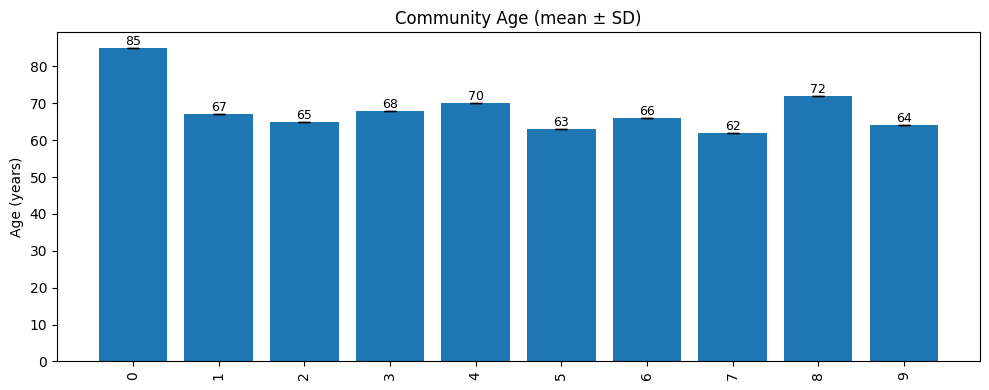

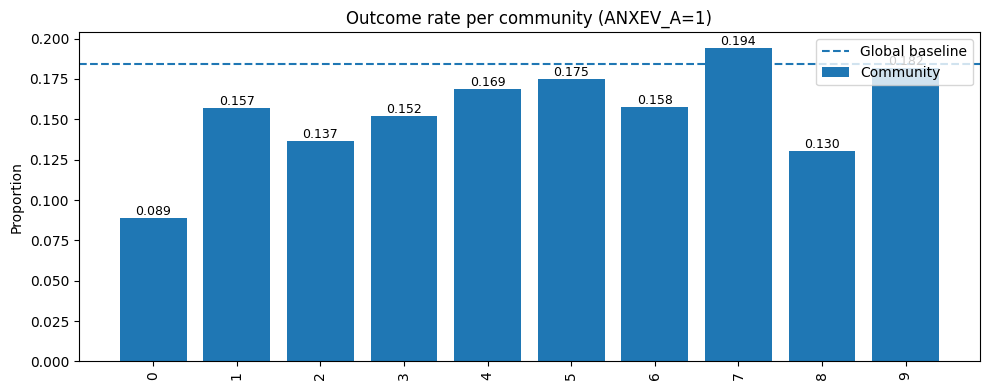

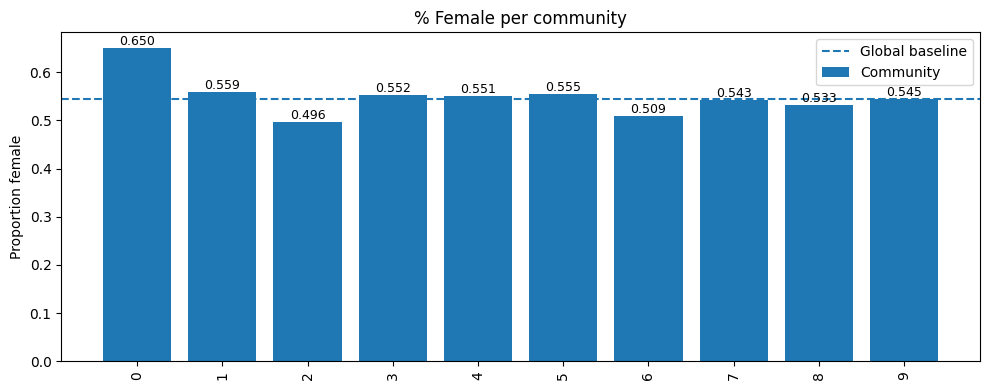

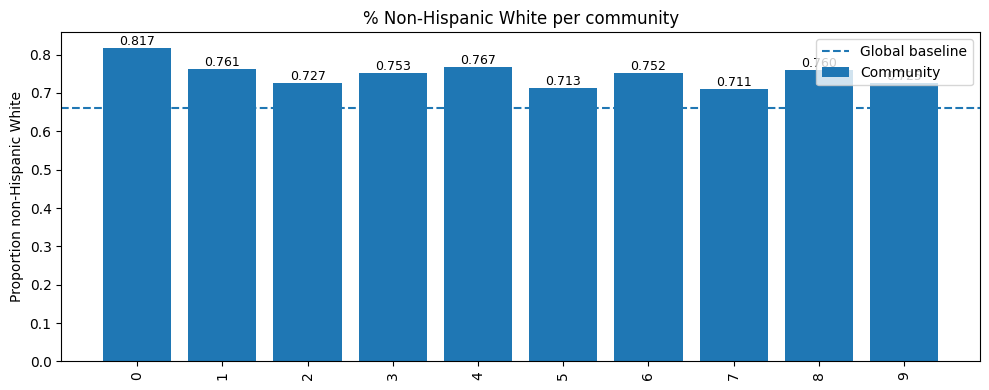

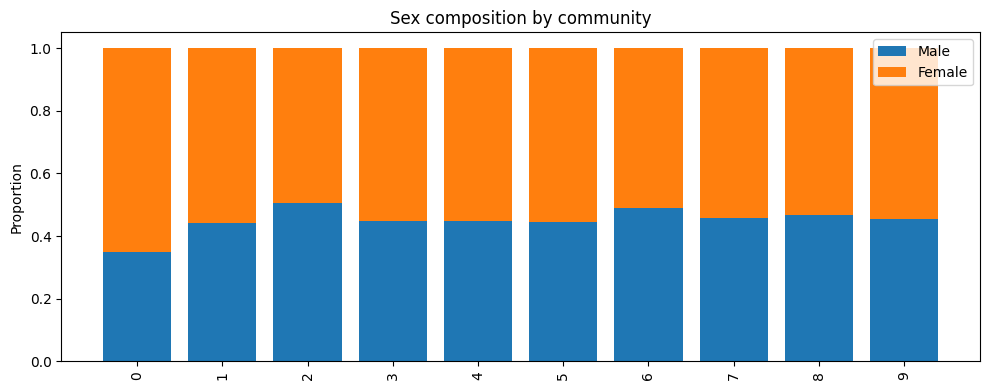

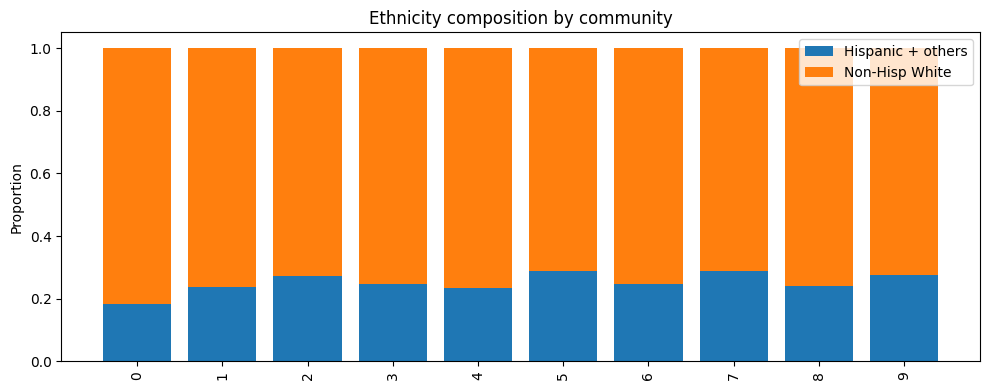

In [9]:
#Visualizing results in graphs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# pick the top N communities by size 
TOPN = 10
top = summary.head(TOPN).reset_index() 
labels = top["community"].astype(int).astype(str).tolist()
x = np.arange(len(top))

# global baselines
g_pos    = df_nodes["ANXEV_A_bin"].mean()
g_female = df_nodes["SEX_A_bin"].mean()
g_nhw    = df_nodes["HISPALLP_BIN"].mean()  # 1 = Non-Hispanic White only

# 1) Age mean ± SD
fig1, ax1 = plt.subplots(figsize=(10,4))
bars = ax1.bar(x, top["age_mean"].values, yerr=top["age_std"].values, capsize=4)
ax1.set_title("Community Age (mean ± SD)")
ax1.set_ylabel("Age (years)")
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=90)
for i, v in enumerate(top["age_mean"].values):
    ax1.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

#Outcome rate P(ANXEV_A=1) per community vs global
fig2, ax2 = plt.subplots(figsize=(10,4))
ax2.bar(x, top["pos_rate"].values)
ax2.axhline(g_pos, linestyle="--")
ax2.set_title("Outcome rate per community (ANXEV_A=1)")
ax2.set_ylabel("Proportion")
ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=90)

# annotate bars
for i, v in enumerate(top["pos_rate"].values):
    ax2.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax2.legend(["Global baseline", "Community"], loc="upper right")
plt.tight_layout()
plt.show()

#  % Female per community vs global
fig3, ax3 = plt.subplots(figsize=(10,4))
ax3.bar(x, top["p_female"].values)
ax3.axhline(g_female, linestyle="--")
ax3.set_title("% Female per community")
ax3.set_ylabel("Proportion female")
ax3.set_xticks(x); ax3.set_xticklabels(labels, rotation=90)
for i, v in enumerate(top["p_female"].values):
    ax3.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax3.legend(["Global baseline", "Community"], loc="upper right")
plt.tight_layout()
plt.show()

# % Non-Hispanic White per community vs global
fig4, ax4 = plt.subplots(figsize=(10,4))
ax4.bar(x, top["p_non_hisp_white"].values)
ax4.axhline(g_nhw, linestyle="--")
ax4.set_title("% Non-Hispanic White per community")
ax4.set_ylabel("Proportion non-Hispanic White")
ax4.set_xticks(x); ax4.set_xticklabels(labels, rotation=90)
for i, v in enumerate(top["p_non_hisp_white"].values):
    ax4.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax4.legend(["Global baseline", "Community"], loc="upper right")
plt.tight_layout()
plt.show()

# Stacked composition bars for Sex and Ethnicity
# Sex composition (Male/Female)
fig5, ax5 = plt.subplots(figsize=(10,4))
male = top["p_male"].values
female = top["p_female"].values
ax5.bar(x, male, label="Male")
ax5.bar(x, female, bottom=male, label="Female")
ax5.set_title("Sex composition by community")
ax5.set_ylabel("Proportion")
ax5.set_xticks(x); ax5.set_xticklabels(labels, rotation=90)
ax5.legend()
plt.tight_layout()

plt.show()

# Ethnicity composition (Hisp+others vs Non-Hisp White)
fig6, ax6 = plt.subplots(figsize=(10,4))
hisp_plus = top["p_hisp_plus_others"].values
nhw = top["p_non_hisp_white"].values
ax6.bar(x, hisp_plus, label="Hispanic + others")
ax6.bar(x, nhw, bottom=hisp_plus, label="Non-Hisp White")
ax6.set_title("Ethnicity composition by community")
ax6.set_ylabel("Proportion")
ax6.set_xticks(x); ax6.set_xticklabels(labels, rotation=90)
ax6.legend()
plt.tight_layout()
plt.show()


In [28]:
#Checking for structural bias 

import numpy as np
from scipy import sparse

A = A.tocsr().astype(np.float64)
A.setdiag(0); A.eliminate_zeros() # remove self-loops & zero entries
if (A - A.T).nnz != 0:         # ensure symmetry
    A = ((A + A.T) * 0.5).tocsr()

def norm(s): 
    return s.astype(str).str.strip().str.lower()

g_sex  = (norm(df_nodes["SEX_A"]) == "female").to_numpy(dtype=int)                 # 0=Male, 1=Female
g_hisp = (norm(df_nodes["HISPALLP_A"]) == "non-hispanic white only").to_numpy(dtype=int)  # 0=Hisp+others, 1=NH White

def weighted_homophily(A, group):
    coo = A.tocoo()  # fast edge-wise access
    same = (group[coo.row] == group[coo.col]).astype(np.float32)
    # numerator = sum of weights where endpoints share the same group
    num = float((same * coo.data).sum())
    den = float(coo.data.sum()) + 1e-12
    return num / den

def expected_same_prob(group):
    counts = np.bincount(group)     # how many 0s and 1s
    p = counts / counts.sum()       # group proportions
    return float((p**2).sum())      # sum_g p_g^2

def degree_parity(A, group):
    deg = np.asarray(A.sum(1)).ravel()  # weighted degree per node
    return float(deg[group==0].mean()), float(deg[group==1].mean())

def neighbor_same_group_exposure(A, group):
    # deg[i] = total incident weight on node i
    deg = (np.asarray(A.sum(1)).ravel() + 1e-12)

    # frac_one[i] = fraction of i’s edge weight that goes to group==1
    frac_one = np.asarray(A.dot(group)) / deg

    # same-group exposure:
    # if node i is in group 1 -> same = frac_one[i]
    # if node i is in group 0 -> same = 1 - frac_one[i]
    same_exp = np.where(group == 1, frac_one, 1.0 - frac_one)

    # average per group
    return float(same_exp[group==0].mean()), float(same_exp[group==1].mean())

def print_structural_summary(name, g, labels):
    h_obs = weighted_homophily(A, g)
    h_exp = expected_same_prob(g)
    d0, d1 = degree_parity(A, g)
    e0, e1 = neighbor_same_group_exposure(A, g)
    print(f"{name}: homophily obs={h_obs:.3f} exp={h_exp:.3f} Δ={h_obs-h_exp:+.3f}")
    print(f"  mean degree: {labels[0]}={d0:.2f}, {labels[1]}={d1:.2f}")
    print(f"  same-group exposure: {labels[0]}={e0:.3f}, {labels[1]}={e1:.3f}")

print_structural_summary("SEX",  g_sex,  {0:"Male", 1:"Female"})
print_structural_summary("HISP", g_hisp, {0:"Hisp+Others", 1:"Non-Hisp White"})


SEX: homophily obs=0.524 exp=0.504 Δ=+0.021
  mean degree: Male=21.63, Female=21.26
  same-group exposure: Male=0.482, Female=0.560
HISP: homophily obs=0.625 exp=0.556 Δ=+0.068
  mean degree: Hisp+Others=19.10, Non-Hisp White=22.59
  same-group exposure: Hisp+Others=0.442, Non-Hisp White=0.719


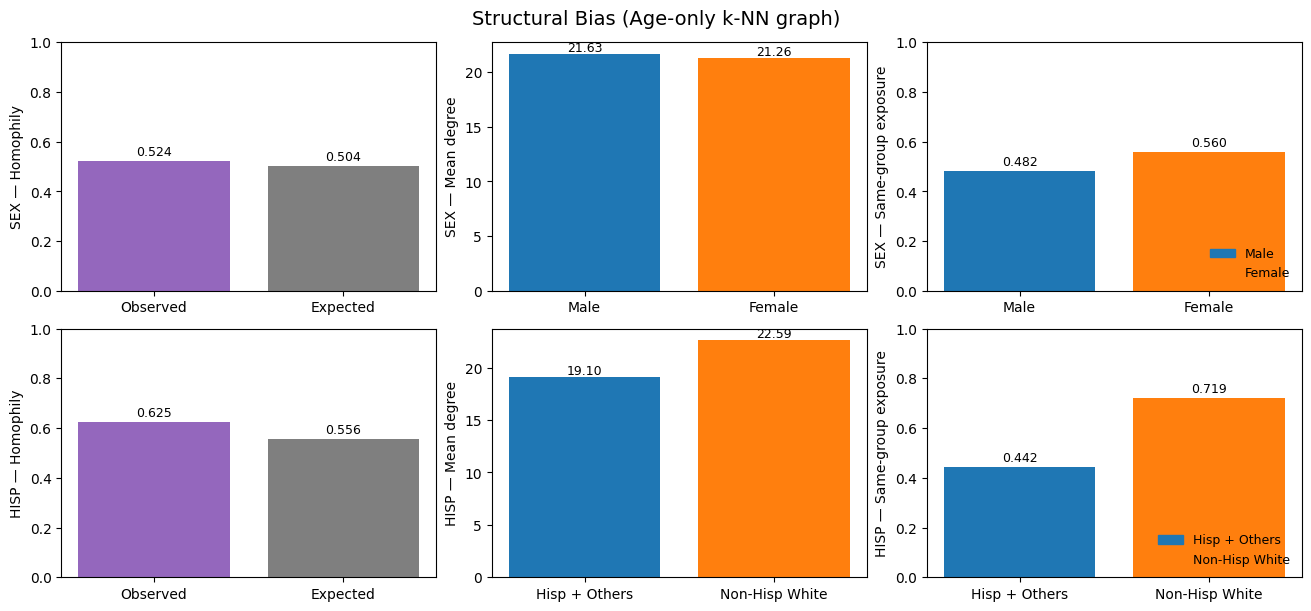

In [34]:
#Visualizing homophily in graphs

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def weighted_homophily(A, group):
    coo = A.tocoo()
    same = (group[coo.row] == group[coo.col]).astype(np.float64)
    num = float((same * coo.data).sum())
    den = float(coo.data.sum()) + 1e-12
    return num / den

def expected_same_prob(group):
    counts = np.bincount(group, minlength=2).astype(np.float64)
    p = counts / counts.sum()
    return float((p**2).sum())

def degree_parity(A, group):
    deg = np.asarray(A.sum(1)).ravel()
    return float(deg[group==0].mean()), float(deg[group==1].mean())

def neighbor_same_group_exposure(A, group):
    deg = (np.asarray(A.sum(1)).ravel() + 1e-12)
    frac_one = np.asarray(A.dot(group)) / deg           # share of weight to group==1
    same_exp = np.where(group == 1, frac_one, 1.0 - frac_one)
    return float(same_exp[group==0].mean()), float(same_exp[group==1].mean())

def _annotate_bars(ax, fmt="{:.3f}", dy=0.0):
    for p in ax.patches:
        h = p.get_height()
        if np.isfinite(h):
            ax.text(p.get_x() + p.get_width()/2, h + dy, fmt.format(h),
                    ha='center', va='bottom', fontsize=9)


def plot_structural_bias_dashboard_labeled(
    A, g_sex, g_hisp,
    sex_labels=("Male","Female"),
    hisp_labels=("Hisp + Others","Non-Hisp White"),
    sex_colors=("tab:blue", "tab:orange"),
    hisp_colors=("tab:blue", "tab:orange"),
    homophily_colors=("tab:purple", "tab:gray"),
    title="Graph Structural Bias Dashboard"
):
    # compute metrics for SEX and HISP
    metrics = {}
    for name, g in [("SEX", g_sex), ("HISP", g_hisp)]:
        h_obs = weighted_homophily(A, g)
        h_exp = expected_same_prob(g)
        d0, d1 = degree_parity(A, g)
        e0, e1 = neighbor_same_group_exposure(A, g)
        metrics[name] = {"h_obs":h_obs, "h_exp":h_exp, "d0":d0, "d1":d1, "e0":e0, "e1":e1}

    label_map = {"SEX": sex_labels, "HISP": hisp_labels}
    color_map   = {"SEX": sex_colors,   "HISP": hisp_colors}

    fig, axes = plt.subplots(2, 3, figsize=(13, 6), constrained_layout=True)

    for r, attr in enumerate(["SEX", "HISP"]):
        m = metrics[attr]
        (lbl0, lbl1) = label_map[attr]
        (c0, c1)     = color_map[attr]
        
        # (col 0) Homophily: observed vs expected
        ax = axes[r, 0]
        ax.bar(["Observed", "Expected"], [m["h_obs"], m["h_exp"]],
               color=homophily_colors)
        ax.set_ylim(0, 1)
        ax.set_ylabel(f"{attr} — Homophily")
        _annotate_bars(ax, "{:.3f}", dy=0.01)

        # (col 1) Mean degree: group 0 vs group 1
        ax = axes[r, 1]
        ax.bar([lbl0, lbl1], [m["d0"], m["d1"]], color=[c0, c1])
        ax.set_ylabel(f"{attr} — Mean degree")
        _annotate_bars(ax, "{:.2f}", dy=0.01)

        # (col 2) Same-group exposure: group 0 vs group 1
        ax = axes[r, 2]
        ax.bar([lbl0, lbl1], [m["e0"], m["e1"]], color=[c0, c1])
        ax.set_ylim(0, 1)
        ax.set_ylabel(f"{attr} — Same-group exposure")
        _annotate_bars(ax, "{:.3f}", dy=0.01)

        legend_patches = [Patch(color=c0, label=lbl0), Patch(color=c1, label=lbl1)]
        axes[r, 2].legend(handles=legend_patches, loc="lower right", frameon=False, fontsize=9)

    fig.suptitle(title, fontsize=14)
    plt.show()



plot_structural_bias_dashboard_labeled(
    A, g_sex, g_hisp,
    sex_labels=("Male","Female"),
    hisp_labels=("Hisp + Others","Non-Hisp White"),
    sex_colors=("tab:blue","tab:orange"),
    hisp_colors=("tab:blue", "tab:orange"),
    homophily_colors=("tab:purple","tab:gray"),
    title="Structural Bias (Age-only k-NN graph)"
)


In [ ]:
#Code sources

#https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html
#https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.kneighbors_graph.html
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csgraph.connected_components.html
#https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.rbf_kernel.html
#https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.kernels.RBF.html
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.save_npz.html
#https://leidenalg.readthedocs.io/en/stable/intro.html
#https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbours/
#https://www.datacamp.com/tutorial/k-nearest-neighbor-classification-scikit-learn
#https://www.youtube.com/watch?v=Nz73vXn5afE
#https://www.youtube.com/watch?v=9-sIgMrMPuY
#https://youtu.be/gGdlYicGIIo?si=tElphyYBEvXdA0Tx
#https://www.geeksforgeeks.org/machine-learning/radial-basis-function-kernel-machine-learning/
#https://machinelearningmastery.com/normalize-standardize-time-series-data-python/
#https://www.youtube.com/watch?v=94f_bId5HGI
#https://machinelearningmastery.com/tutorial-to-implement-k-nearest-neighbors-in-python-from-scratch/
#https://www.w3schools.com/python/python_ml_knn.asp
#https://towardsdatascience.com/k-nearest-neighbor-classifier-explained-a-visual-guide-with-code-examples-for-beginners-a3d85cad00e1/
#https://medium.com/analytics-vidhya/implementing-k-nearest-neighbours-knn-without-using-scikit-learn-3905b4decc3c
#https://medium.com/@swapnil.agashe456/leiden-clustering-for-community-detection-a-step-by-step-guide-with-python-implementation-c883933a1430
#https://github.com/CWTSLeiden/networkanalysis
#https://github.com/vtraag/leidenalg



